<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Lecture 15

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

**What:** A lecture of the "3dasm" course

**Where:** This notebook comes from this [repository](https://github.com/bessagroup/3dasm_course)

**Reference for entire course:** Murphy, Kevin P. *Probabilistic machine learning: an introduction*. MIT press, 2022. Available online [here](https://probml.github.io/pml-book/book1.html)

**How:** We try to follow Murphy's book closely, but the sequence of Chapters and Sections is different. The intention is to use notebooks as an introduction to the topic and Murphy's book as a resource.
* If working offline: Go through this notebook and read the book.
* If attending class in person: listen to me (!) but also go through the notebook in your laptop at the same time. Read the book.
* If attending lectures remotely: listen to me (!) via Zoom and (ideally) use two screens where you have the notebook open in 1 screen and you see the lectures on the other. Read the book.

**Optional reference (the "bible" by the "bishop"... pun intended 😆) :** Bishop, Christopher M. *Pattern recognition and machine learning*. Springer Verlag, 2006.

**References/resources to create this notebook:**
* This simple tutorial is still based on a script I created for this article: https://imechanica.org/node/23957
* It follows from some examples provided by the scikit-learn user guide, which seem to have originated from Mathieu Blondel, Jake Vanderplas, Vincent Dubourg, and Jan Hendrik Metzen.

## **OPTION 1**. Run this notebook **locally in your computer**:
1. Confirm that you have the '3dasm' mamba (or conda) environment (see Lecture 1).
2. Go to the 3dasm_course folder in your computer and pull the last updates of the [repository](https://github.com/bessagroup/3dasm_course):
```
git pull
```
    - Note: if you can't pull the repo due to conflicts (and you can't handle these conflicts), use this command (with **caution**!) and your repo becomes the same as the one online:
```
git reset --hard origin/main
```
3. Open command window and load jupyter notebook (it will open in your internet browser):
```
jupyter notebook
```
5. Open notebook of this Lecture and choose the '3dasm' kernel.

## **OPTION 2**. Use **Google's Colab** (no installation required, but times out if idle):

1. go to https://colab.research.google.com
2. login
3. File > Open notebook
4. click on Github (no need to login or authorize anything)
5. paste the git link: https://github.com/bessagroup/3dasm_course
6. click search and then click on the notebook for this Lecture.

In [1]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!
from IPython.display import display, Math # to print with Latex math

%config InlineBackend.figure_format = "retina" # render higher resolution images in the notebook
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

## Outline for today

* Gaussian process regression in practice, **with an AI coding agent**
    - The agent writes a first GP, and we check it against the PPD of Lecture 14
    - The hyperparameters $s$ and $l$, with the optimizer off and on, and the choice of kernel
    - Noise: known at each point, or learned from the data (aleatoric uncertainty, as in Lecture 13)

**Reading material**: This notebook + Section 17.2 of the book.

**Optional reading material (GPs bible)**: Rasmussen, Carl E. *Gaussian Processes for Machine Learning*. MIT press, 2006. Available online [here](https://gaussianprocess.org/gpml/chapters/RW.pdf)

## Gaussian processes

Last lecture we saw that Gaussian processes (GPs) are a kernel machine learning method. Today we will see GPs in action, on the function of the previous lectures, $f(x) = x \sin(x)$, in one dimension:

* We will develop an intuition for the influence of the different hyperparameters in GPs.
* You will discover that the hyperparameters of GPs are not just pre-assumed values that we impose in the prior! Instead, GP "training" includes hyperparameter optimization... Lecture 17 explains how GP packages optimize the hyperparameters.

Today, we are focusing on learning how to do Gaussian Process regression for one-dimensional datasets.

We will consider the function to be learned the same that we used in previous lectures $f(x) = x \sin(x)$

In [2]:
from sklearn.model_selection import train_test_split

# Function to "learn"
def f(x):
    return x * np.sin(x)

n_data = 50 # number of points in our dataset
testset_ratio = 0.75 # ratio of test set points from the dataset
x_data = np.linspace(0, 10, n_data) # create dataset with uniformly spaced points
y_data = f(x_data) # function values at x_data

X_data = np.reshape(x_data,(-1,1)) # a 2D array that scikit-learn likes

seed = 1987 # the seed of the split (and of the noise, later)

# Let's split into 10% training points and the rest for testing:
X_train, X_test, y_train, y_test = train_test_split(X_data,
                                    y_data, test_size=testset_ratio,
                                    random_state=seed)

x_train = X_train.ravel() # just for plotting later
x_test = X_test.ravel() # just for plotting later

print("Here's a print of X_train:\n", X_train)

Here's a print of X_train:
 [[4.28571429]
 [3.46938776]
 [1.42857143]
 [7.95918367]
 [5.10204082]
 [2.04081633]
 [1.2244898 ]
 [6.12244898]
 [8.57142857]
 [7.14285714]
 [2.85714286]
 [8.97959184]]


## Recap: the PPD of a Gaussian process (Lecture 14)

With zero prior mean and homoscedastic noise $\sigma^2$ (scikit-learn calls it ${\color{red}\alpha} = \sigma^2$):

$$
{\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid
{\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1}\mathbf{y} \,,\, k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1} \mathbf{k}^*\right)
$$

with the kernel matrix $\mathbf{K}$ ($K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ at the training points) and the kernel vector $\mathbf{k}^*$ ($k_j^* = k(\mathbf{x}_j, \mathbf{x}^*)$). With the most common kernel, Constant $\times$ RBF,

$$
k(x_i,x_j) = {\color{red}s}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)},
$$

the whole PPD depends on **two hyperparameters**, $s$ and $l$ (plus the noise), and on no parameter: a **non-parametric** model.

#### Notes: the recap in detail

## Gaussian processes with <font color='red'>homoscedastic noise</font>

Let's recap the PPD of Gaussian processes assuming **homoscedastic noise** we found in the last Lecture:



$${\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid \mu^* +
{\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1}(\mathbf{y}-\boldsymbol{\mu}) \,,\, {\sigma^*}^2 + k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+{\color{red}\sigma^2}\mathbf{I}_N)^{-1} \mathbf{k}^*\right)
$$

However, usually most ML packages assume a zero mean function $\mu^*=\mu(\mathbf{x}^*)=0$ (and so also $\boldsymbol{\mu}=\mathbf{0}$ at the training points) (usually also assuming a prior on the "weights" with zero mean), and a zero variance function ${\sigma^*}^2=\sigma(\mathbf{x}^*)^2=0$.

In the case of <font color='red'>homoscedastic noise</font>, this means that ${\color{red}\sigma^2}$ is constant for all $N$ training points, i.e. $\sigma(\mathbf{x}_n)^2 = \sigma^2$. So, the usual PPD for homoscedastic noise that most ML packages assume is:

$$
{\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid 
{\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1}\mathbf{y} \,,\, k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1} \mathbf{k}^*\right)
$$

* In the scikit-learn package, they call ${\color{red}\alpha}$ to $\sigma^2$, i.e. $\sigma^2 = \alpha$. In a non-Bayesian perspective (of models like Ridge regression), sometimes you see people calling $\alpha$ the Tikhonov regularization.

For completeness, remember that the PPD of GPs depends on the **kernel function**:

$$
k(\mathbf{x}^*, \mathbf{x}^*) \quad \text{where $k$ is a chosen kernel function}
$$

the **kernel vector**:

$$
{\mathbf{k}^*}^T = [k(\mathbf{x}_1, \mathbf{x}^*), k(\mathbf{x}_2, \mathbf{x}^*), \ldots, k(\mathbf{x}_N, \mathbf{x}^*) ] \quad \text{where $N$ is the number of training points}
$$


and the kernel matrix a.k.a. **Covariance matrix**:  

$$
\mathbf{K} = \begin{bmatrix} k(\mathbf{x}_1, \mathbf{x}_1) & k(\mathbf{x}_1, \mathbf{x}_2) & \cdots & k(\mathbf{x}_1, \mathbf{x}_N) \\
k(\mathbf{x}_2, \mathbf{x}_1) & k(\mathbf{x}_2, \mathbf{x}_2) & \cdots & k(\mathbf{x}_2, \mathbf{x}_N) \\
\vdots & \vdots & \ddots & \vdots \\
k(\mathbf{x}_N, \mathbf{x}_1) & k(\mathbf{x}_N, \mathbf{x}_2) & \cdots & k(\mathbf{x}_N, \mathbf{x}_N) \\
\end{bmatrix}
$$

By far the most common kernel used in GPs is a kernel that results from multiplying a Constant kernel (with hyperparameter $s^2$) by the RBF kernel (with hyperparameter $l$):

$$
k(x_i,x_j) = {\color{red}s}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)}
$$

In this case, the entire PPD only depends on **two hyperparameters** ($s^2$ and $l$) and it does not explicitly depend on any parameter! This is also why GPs are often called a **non-parametric** ML model, although they have hyperparameters!

I am showing the PPD for homoscedastic noise here again for you to confirm this:

$$
{\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid 
{\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1}\mathbf{y} \,,\, k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+\sigma^2\mathbf{I}_N)^{-1} \mathbf{k}^*\right)
$$

#### Note: what exactly does the blue band represent?

In the PPD above we set the variance function at the prediction point to zero, $\sigma(\mathbf{x}^*)^2=0$. That is a statement about the new point: we are predicting a **noise-free** output, i.e. the latent function $f(\mathbf{x}^*)$ itself.

So the 95% interval of this PPD, $\mu \pm 1.96\,\sigma_{\text{pred}}$, is a **credible interval for $f(\mathbf{x}^*)$**. It is *not* an interval for a new noisy measurement $y^*$. For that we would add the noise variance at the new point, $\sigma(\mathbf{x}^*)^2$, and obtain a wider **posterior predictive interval for $y^*$**.

In scikit-learn this depends on *how* the noise is given to the model:

* noise given through `alpha`: `predict(..., return_std=True)` **excludes** it $\Rightarrow$ credible interval for $f(\mathbf{x}^*)$;
* noise modelled with a `WhiteKernel`: the returned std **includes** it $\Rightarrow$ posterior predictive interval for $y^*$.

For the noiseless data of this first example the two coincide (the noise is negligible). They will **not** coincide for the noisy data later in this lecture.

## Ask the agent for a first GP, and check it

We ask an agent for the code of one Gaussian process, and we **check** it against something we know: the PPD formulas of
Lecture 14. Then the code is ours: we change the kernel and its hyperparameters ourselves, in the notebook.

In [3]:
# The helper that runs a coding agent from this notebook (the same one you use in the homework)
import sys; sys.path.insert(0, "../..") # the root folder of the 3dasm_course, where agent_helper.py is
from agent_helper import set_model, set_workspace, run_agent, results, figures, show

set_model("sonnet") # the models of this course: "sonnet" or "haiku"
set_workspace("agent_work") # the task folders go in agent_work/ (not tracked by git: each of you runs your own agents)

In [4]:
%%writefile CLAUDE.md
# Lectures 15 and 16 of the 3dasm course (Gaussian processes)

You write and run Python code for a lecture. The notebook loads your results automatically, so follow the rules below
exactly.

## Environment
- Use the `python` command: it is this notebook's environment, with numpy, scipy, pandas, matplotlib and
  scikit-learn. Do not install anything.
- The course data folder is `../../../data/` (from your task folder): read the data, never modify them.
- Never edit `CLAUDE.md`.

## Packages
- Use scikit-learn for the models and the error metrics, numpy for the linear algebra, matplotlib for the figures.

## Files (the notebook depends on them)
- Work only in your task folder (the folder you start in): write every file there.
- Write your code as Python scripts, not notebooks.
- Put the numbers the notebook needs in `results.json`, with exactly the keys the prompt asks for. Save figures as
  PNG files.

## Randomness
- Use randomness only where the prompt asks for it, with the seed the prompt gives.
- Running the script twice must give identical files.

## Scope
- Do exactly what the prompt asks, with the methods it names. Do not add steps, models or checks that the prompt
  does not ask for.
- If the prompt leaves a choice open, make the simplest choice, do the task, and list the choice under
  "Assumptions" in your summary.
- If a result looks wrong or surprising, do NOT fix it: complete the task as asked and say so in your summary.

## Summary
End with: the files you wrote, the numbers you stored (with their keys), and your Assumptions.

Overwriting CLAUDE.md


*Presenter note:* the same rules as the instructions file of Lectures 10 and 11; only the title changed.

In [5]:
TASK_GP = "gp_check"
PROMPT_GP = """Data: x = np.linspace(0, 10, 50), y = x sin(x), split with train_test_split(x as a column, y, test_size=0.75,
random_state=1987).
Write gp_check.py, which fits scikit-learn's GaussianProcessRegressor with the kernel ConstantKernel(1.0) * RBF(1.0),
alpha=1e-6 and optimizer=None (the hyperparameters stay fixed) to the training points, and predicts the mean and the
standard deviation at x* = np.linspace(-10, 20, 301).
Then compute the same mean and standard deviation with numpy, from the PPD of a Gaussian process:
mean = k*^T (K + 1e-6 I)^{-1} y and std = sqrt(k(x*, x*) - k*^T (K + 1e-6 I)^{-1} k*), where K is the kernel matrix of the
training inputs, k* the kernel vector, and k(a, b) = exp(-(a - b)^2 / 2).
results.json keys: "max_abs_diff_mean" and "max_abs_diff_std" (between scikit-learn and numpy, over x*). No figure."""
run_agent(TASK_GP, PROMPT_GP)

[gp_check] the prompt, the model, the instructions or the helper changed: emptying agent_work/gp_check and running again.


[gp_check] ran in 16 s with model sonnet (claude-sonnet-5).
What it did (from the transcript):
  Bash  pwd && ls
  Write gp_check.py
  Bash  python gp_check.py && cat results.json
  Bash  python gp_check.py && cat results.json

Files the agent made:
  gp_check.py
  results.json

--- the code it wrote: gp_check.py ---
import json

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.model_selection import train_test_split

x = np.linspace(0, 10, 50)
y = x * np.sin(x)

x_train, x_test, y_train, y_test = train_test_split(
    x.reshape(-1, 1), y, test_size=0.75, random_state=1987
)

kernel = ConstantKernel(1.0) * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, optimizer=None)
gp.fit(x_train, y_train)

x_star = np.linspace(-10, 20, 301).reshape(-1, 1)
mean_sklearn, std_sklearn = gp.predict(x_star, return_std=True)


def k(a, b):
    return np.exp(-(a - b) ** 2 / 2)




*Presenter note:* show the few lines that fit the model with scikit-learn, and the two lines that compute the mean and the variance with numpy: the PPD of Lecture 14, written by the agent and compared.

In [6]:
r = results(TASK_GP, ["max_abs_diff_mean", "max_abs_diff_std"])
print("largest difference between scikit-learn and the PPD formulas: mean %.1e, std %.1e"
      % (r["max_abs_diff_mean"], r["max_abs_diff_std"]))

largest difference between scikit-learn and the PPD formulas: mean 2.1e-13, std 5.9e-11


## Gaussian process regression on <font color='red'>noiseless data</font>

Let's make our first prediction using Gaussian processes for a noiseless dataset.

We will use a kernel that results from multiplying a Constant kernel (with hyperparameter $s^2$) by the RBF kernel (with hyperparameter $l$):

$$
k(x_i,x_j) = {\color{red}s}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)}
$$

with an initial guess for the hyperparameters as: $s = 1$ and $l = 10$.

#### Notes: the first GP

### Gaussian Process Regression (GPR) for noiseless datasets

Let's make our first prediction using Gaussian processes for a noiseless dataset.

We will use a kernel that results from multiplying a Constant kernel (with hyperparameter $s^2$) by the RBF kernel (with hyperparameter $l$):

$$
k(x_i,x_j) = {\color{red}s}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)}
$$

with an initial guess for the hyperparameters as: $s = 1$ and $l = 10$.

In [7]:
# @title Plotting helper (hidden): the data, f(x), and a GP's mean with its 95% band
def plot_gp(ax, x_plot, mean, std, title, x_tr, y_tr, x_te=None, y_te=None, band="95% credible interval of $f(x^*)$",
            errorbars=None, ylim=None):
    ax.plot(x_plot, f(x_plot), 'r:', label='ground truth: $f(x) = x\\sin(x)$')
    ax.plot(x_plot, mean, 'b-', label="GPR mean")
    ax.fill_between(x_plot, mean - 1.96 * std, mean + 1.96 * std, color='b', alpha=0.25,
                    lw=0, label=band)
    if errorbars is None:
        ax.plot(x_tr, y_tr, 'ro', ms=6, label="training points")
    else:
        ax.errorbar(x_tr, y_tr, 1.96 * errorbars, fmt='ro', ms=6, label="training points ($\\pm 1.96\\sigma_i$)")
    if x_te is not None:
        ax.plot(x_te, y_te, 'kX', ms=6, label="testing points")
    ax.set_title(title, fontsize=11); ax.set_xlabel('$x$', fontsize=14)
    if ylim:
        ax.set_ylim(*ylim)

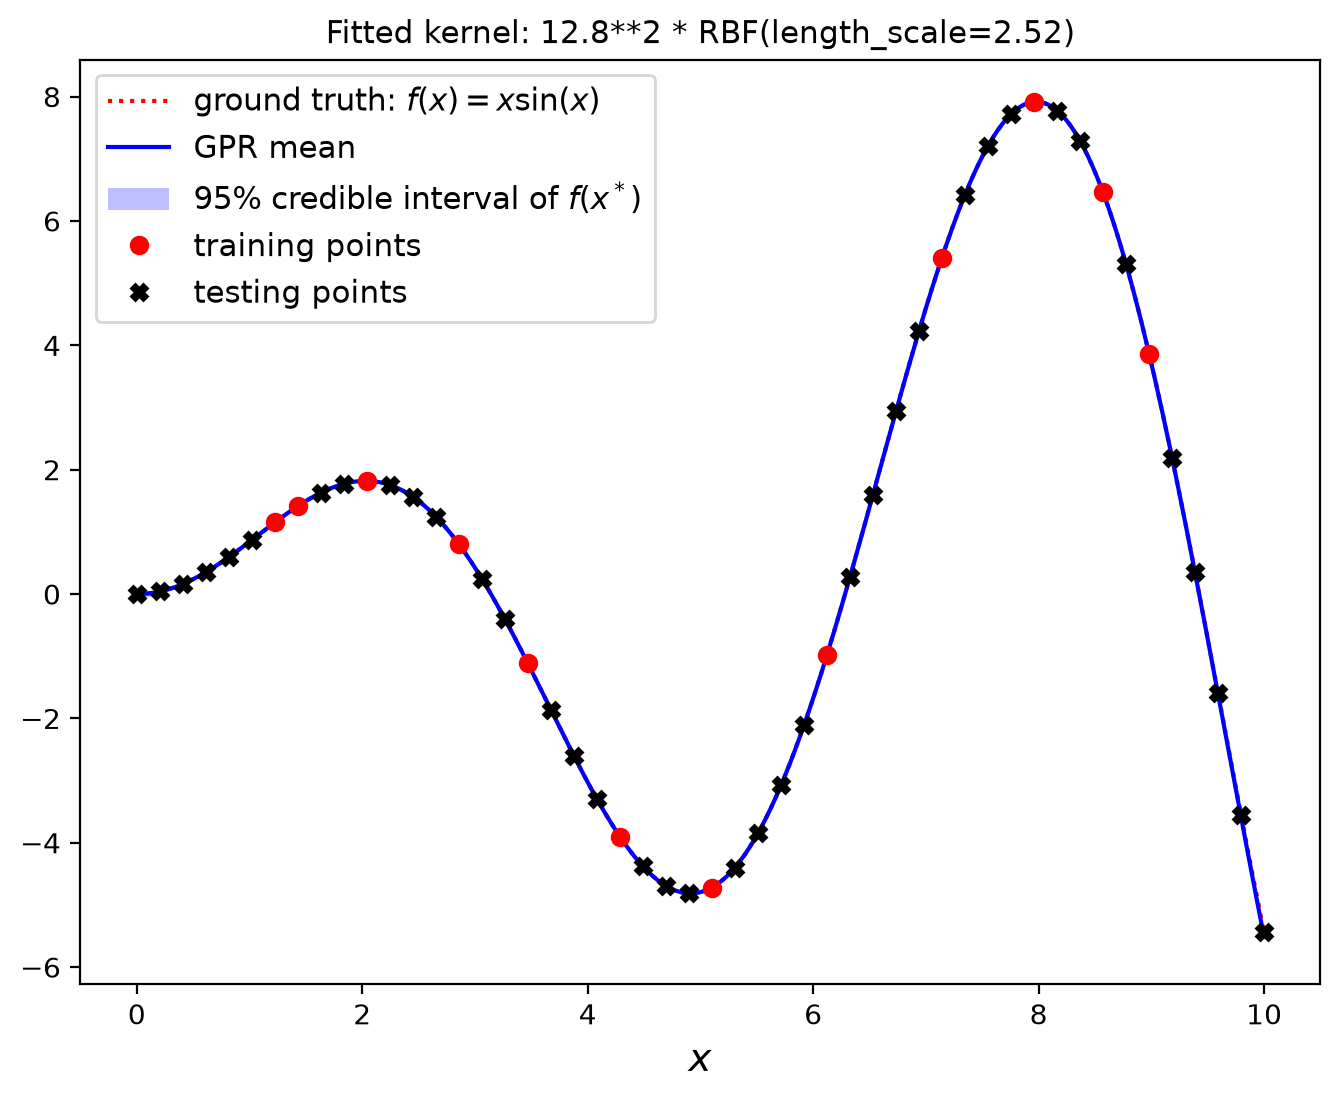

In [8]:
import warnings; from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning) # the optimizer's warnings about bounds (we read the fitted kernels instead)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, ConstantKernel, WhiteKernel

x_plot = np.linspace(0, 10, 500) # try np.linspace(-10, 20, 500): what does the GP do far from the data?

# The kernel: s^2 * RBF(l), with s = 1 and l = 10 as the initial guess, and the bounds the optimizer can explore
kernel = ConstantKernel(1.0**2, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
#kernel = ConstantKernel(1.0**2, (1e-3, 1e3)) * Matern(1.0, (1e-2, 1e2), nu=1.5) # try other kernels

gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, n_restarts_optimizer=5, random_state=0)
#gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, optimizer=None) # keep s and l as given
gp_model.fit(X_train, y_train)
mean, std = gp_model.predict(x_plot.reshape(-1, 1), return_std=True)

fig1, ax1 = plt.subplots(figsize=(8, 6))
plot_gp(ax1, x_plot, mean, std, "Fitted kernel: " + str(gp_model.kernel_), x_train, y_train, x_test, y_test)
ax1.legend(loc='upper left', fontsize=11); plt.close(fig1)
fig1

## The hyperparameters, with the optimizer turned off

Now on a larger domain, $x \in [-10, 20]$, so that we also see the model **extrapolating**. Move the sliders: $l$ and $s$
are fixed (no optimizer), and the noise can be negligible or $\sigma = 2.5$ at every training point ($\alpha = \sigma^2$).

In [9]:
# @title Figure code: the GP for a grid of fixed hyperparameters (the optimizer off)
x_wide = np.linspace(-10, 20, 201)
l_grid = np.round(np.logspace(-1, 1, 17), 4)                 # 0.1 to 10
s_grid = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
noise_opts = [("negligible noise", 1e-10), ("noise sigma = 2.5", 2.5**2)]
def _fixed_gp(l, s, a):
    m = GaussianProcessRegressor(ConstantKernel(s**2) * RBF(l), alpha=a, optimizer=None).fit(X_train, y_train)
    mean, std = m.predict(x_wide.reshape(-1, 1), return_std=True)
    return dict(mean=mean, std=std)
_fits = {name: [[_fixed_gp(l, s, a) for s in s_grid] for l in l_grid] for name, a in noise_opts}

# Static version: four combinations, negligible noise
fig_hyp, axs = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, (li, si) in zip(axs.ravel(), [(8, 1), (0, 1), (8, 4), (16, 1)]):   # (l=1, s=1), (l=0.1, s=1), (l=1, s=2.5), (l=10, s=1)
    _r = _fits["negligible noise"][li][si]
    plot_gp(ax, x_wide, _r["mean"], _r["std"], f"$l$ = {l_grid[li]:g}, $s$ = {s_grid[si]:g} (optimizer off)",
            x_train, y_train, ylim=(-15, 20))
axs[0, 0].legend(loc="upper left", fontsize=9)
fig_hyp.tight_layout(); plt.close(fig_hyp)

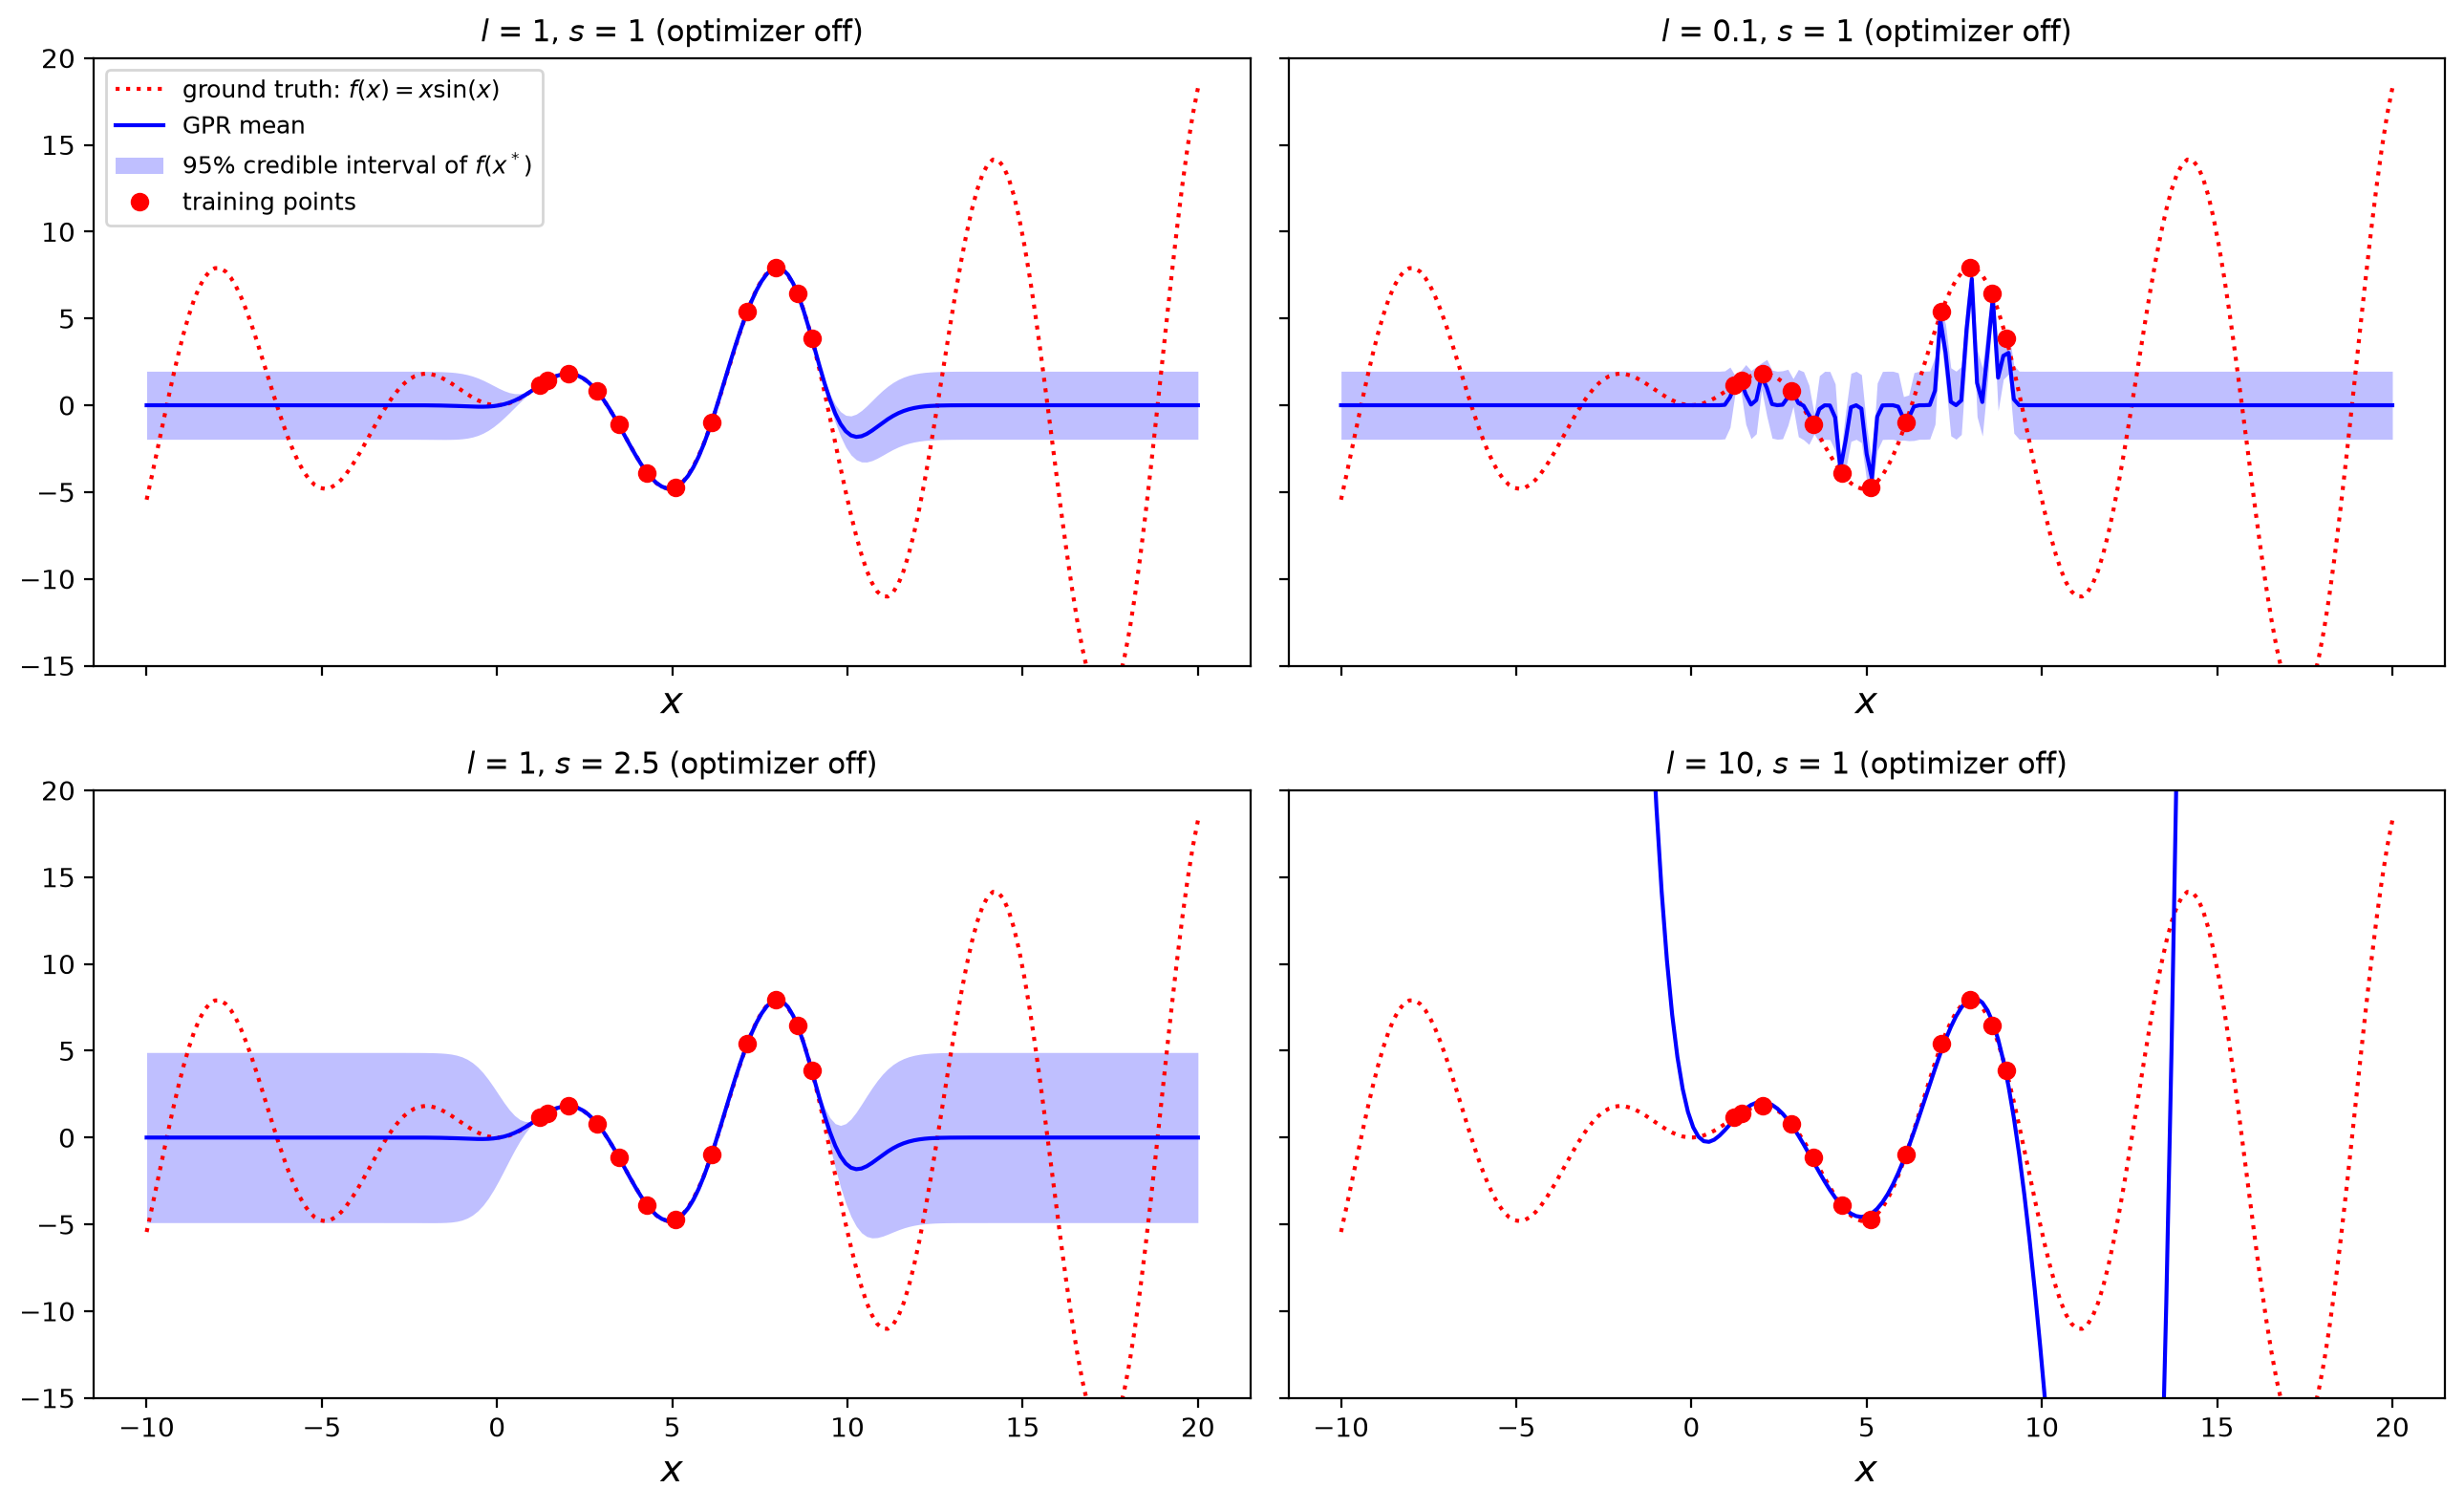

In [10]:
# @title Static version (skipped in the deck): what GitHub, nbviewer and a PDF export show
fig_hyp

In [11]:
# @title Figure code: interactive GP (sliders for l and s, buttons for the noise)
# Hidden. Pattern documented in Lectures/INTERACTIVE_PLOTS.md: the sliders slice a precomputed field (the fits above);
# no Gaussian process algebra in the renderer.
import json as _json
from IPython.display import HTML
_SC = 100.0
_gp_data = dict(x=[round(float(v), 3) for v in x_wide], f=[round(float(v), 3) for v in f(x_wide)],
                xt=[round(float(v), 4) for v in x_train], yt=[round(float(v), 4) for v in y_train],
                ls=[float(v) for v in l_grid], ss=s_grid, noises=[n for n, _ in noise_opts], sc=_SC,
                mean={n: [[np.round(r["mean"] * _SC).astype(int).tolist() for r in row] for row in _fits[n]] for n, _ in noise_opts},
                std={n: [[np.round(r["std"] * _SC).astype(int).tolist() for r in row] for row in _fits[n]] for n, _ in noise_opts})
_gp_plot = HTML(r"""<div id="__ID__-w" style="font-family:system-ui,sans-serif">
<div style="display:flex;gap:18px;flex-wrap:wrap;align-items:center;font-size:13px;margin-bottom:4px">
 <span id="__ID__-n"></span>
 <label style="display:inline-flex;align-items:center;gap:6px">length scale <i>l</i>
   <input id="__ID__-l" type="range" style="width:200px"><span id="__ID__-lv" style="min-width:44px"></span></label>
 <label style="display:inline-flex;align-items:center;gap:6px">amplitude <i>s</i>
   <input id="__ID__-s" type="range" style="width:150px"><span id="__ID__-sv" style="min-width:30px"></span></label>
</div>
<canvas id="__ID__-c" width="__CW__" height="__CH__" style="width:__W__px;height:__H__px"></canvas>
<div id="__ID__-leg" style="font-size:12.5px;line-height:1.8;margin-top:2px"></div>
</div>
<script>
(function(){
 var D=__DATA__, S=2, noise=D.noises[0];
 var c=document.getElementById('__ID__-c'), g=c.getContext('2d');
 var sl=document.getElementById('__ID__-l'), ss=document.getElementById('__ID__-s'), nb=document.getElementById('__ID__-n');
 D.noises.forEach(function(n){var b=document.createElement('button');b.textContent=n;b.style.marginRight='4px';
   b.onclick=function(){noise=n;draw();};nb.appendChild(b);});
 sl.min=0; sl.max=D.ls.length-1; sl.step=1; sl.value=8; ss.min=0; ss.max=D.ss.length-1; ss.step=1; ss.value=1;
 var L=52*S,R=14*S,T=24*S,B=36*S, PW=c.width-L-R, PH=c.height-T-B, xmin=D.x[0], xmax=D.x[D.x.length-1], ymin=-15, ymax=20;
 function X(v){return L+(v-xmin)/(xmax-xmin)*PW;} function Y(v){return T+(ymax-v)/(ymax-ymin)*PH;}
 function line(vals,col,w,dash){g.save();g.strokeStyle=col;g.lineWidth=w*S;if(dash)g.setLineDash(dash);g.beginPath();
   for(var i=0;i<vals.length;i++){var x=X(D.x[i]),y=Y(Math.max(ymin-5,Math.min(ymax+5,vals[i])));if(i)g.lineTo(x,y);else g.moveTo(x,y);}
   g.stroke();g.restore();}
 function draw(){
  var li=+sl.value, si=+ss.value, m=D.mean[noise][li][si], sd=D.std[noise][li][si];
  document.getElementById('__ID__-lv').textContent=D.ls[li].toFixed(2);
  document.getElementById('__ID__-sv').textContent=D.ss[si].toFixed(1);
  Array.prototype.forEach.call(nb.children,function(b){b.style.fontWeight=(b.textContent==noise)?'bold':'normal';});
  g.clearRect(0,0,c.width,c.height);
  g.save();g.beginPath();g.rect(L,T,PW,PH);g.clip();
  g.fillStyle='rgba(31,119,180,0.25)';g.beginPath();
  for(var i=0;i<m.length;i++){var y=(m[i]+1.96*sd[i])/D.sc;if(i)g.lineTo(X(D.x[i]),Y(y));else g.moveTo(X(D.x[i]),Y(y));}
  for(var i=m.length-1;i>=0;i--){g.lineTo(X(D.x[i]),Y((m[i]-1.96*sd[i])/D.sc));}
  g.closePath();g.fill();
  line(D.f,'#d62728',1.6,[4*S,4*S]); line(m.map(function(v){return v/D.sc;}),'#1f3fb4',2.2);
  g.fillStyle='#d62728';for(var i=0;i<D.xt.length;i++){g.beginPath();g.arc(X(D.xt[i]),Y(D.yt[i]),4.5*S,0,7);g.fill();}
  g.restore();
  g.save();g.strokeStyle='#ccc';g.lineWidth=S;g.strokeRect(L,T,PW,PH);g.fillStyle='#555';g.font=(11*S)+'px system-ui';
  g.textAlign='center';for(var k=-10;k<=20;k+=5){g.fillText(k,X(k),T+PH+16*S);}
  g.textAlign='right';for(var k=-15;k<=20;k+=5){g.fillText(k,L-6*S,Y(k)+4*S);}
  g.textAlign='center';g.font=(13*S)+'px system-ui';g.fillStyle='#222';
  g.fillText('GP with fixed hyperparameters: l = '+D.ls[li].toFixed(2)+', s = '+D.ss[si].toFixed(1)+' ('+noise+')',L+PW/2,T-8*S);g.restore();
  document.getElementById('__ID__-leg').innerHTML='<span style="color:#d62728">&#9679;</span> training points &nbsp; '+
   '<span style="color:#d62728">- -</span> f(x) = x sin(x) &nbsp; <span style="color:#1f3fb4">&#8212;</span> GP mean &nbsp; '+
   '<span style="color:rgba(31,119,180,0.6)">&#9632;</span> 95% credible interval of f(x*) (far from the data: &plusmn;1.96 s = &plusmn;'+(1.96*D.ss[si]).toFixed(1)+')';
 }
 sl.addEventListener('input',draw); ss.addEventListener('input',draw); draw();
})();
</script>
""".replace('__DATA__', _json.dumps(_gp_data, separators=(',', ':'))).replace('__ID__', 'g14')
   .replace('__W__', '860').replace('__H__', '440').replace('__CW__', '1720').replace('__CH__', '880'))

In [12]:
_gp_plot

### Reading the hyperparameters

* $l$ is the **length scale**: how far apart two inputs can be and still have similar $f$. Small $l$: a rough mean that
  returns to zero between the points; large $l$: a smooth, stiff mean (the "roughness" parameter).
* $s^2$ is the **variance** of the prior: far from the data, the band is $\pm 1.96\,s$, the prior uncertainty. It is the
  scale of the **epistemic** uncertainty.
* Far from the data, the mean returns to **zero**: the mean of the prior.
* With noise $\sigma = 2.5$ at the training points ($\alpha = \sigma^2$, **aleatoric**), the mean no longer passes through
  the points, and the band does not shrink to zero at them.

## The optimizer on, and the choice of kernel

Now the hyperparameters are **optimized** (Lecture 17 explains how), for three kernels. A polynomial of degree 4 (Linear
Least Squares, inputs rescaled to $[-1, 1]$) is our reference.

In [13]:
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

x_ext = np.linspace(-5, 15, 400)                     # to see what each model believes outside the data
fig2, axs2 = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
kernels = {"RBF": ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)),
           "Matern 3/2": ConstantKernel(1.0, (1e-3, 1e3)) * Matern(1.0, (1e-2, 1e2), nu=1.5),
           "periodic": ConstantKernel(1.0, (1e-3, 1e3)) * ExpSineSquared(1.0, periodicity=5.0,
                                       length_scale_bounds=(1e-2, 1e2), periodicity_bounds=(1e-1, 10))}
rows = {}
for ax, (name, kernel) in zip(axs2, kernels.items()):
    gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, n_restarts_optimizer=5, random_state=0)
    gp_model.fit(X_train, y_train)
    mean, std = gp_model.predict(x_ext.reshape(-1, 1), return_std=True)
    pred = gp_model.predict(X_test)
    rows[name] = [r2_score(y_test, pred), mean_squared_error(y_test, pred), str(gp_model.kernel_)]
    plot_gp(ax, x_ext, mean, std, f"{name}:\n{gp_model.kernel_}", x_train, y_train, x_test, y_test, ylim=(-20, 25))
poly = make_pipeline(MinMaxScaler((-1, 1)), PolynomialFeatures(4), LinearRegression()).fit(X_train, y_train)
p = poly.predict(X_test)
rows["polynomial, degree 4"] = [r2_score(y_test, p), mean_squared_error(y_test, p), ""]
axs2[0].legend(loc="upper left", fontsize=9); fig2.tight_layout(); plt.close(fig2)
print(pd.DataFrame(rows, index=["test R2", "test MSE", "fitted kernel"]).T.to_string())

                       test R2   test MSE                                                 fitted kernel
RBF                   0.999986   0.000182                              12.8**2 * RBF(length_scale=2.52)
Matern 3/2            0.885651    1.54444                   4.55**2 * Matern(length_scale=2.49, nu=1.5)
periodic              0.927094     0.9847  4.21**2 * ExpSineSquared(length_scale=0.861, periodicity=10)
polynomial, degree 4 -1.065167  27.893016                                                              


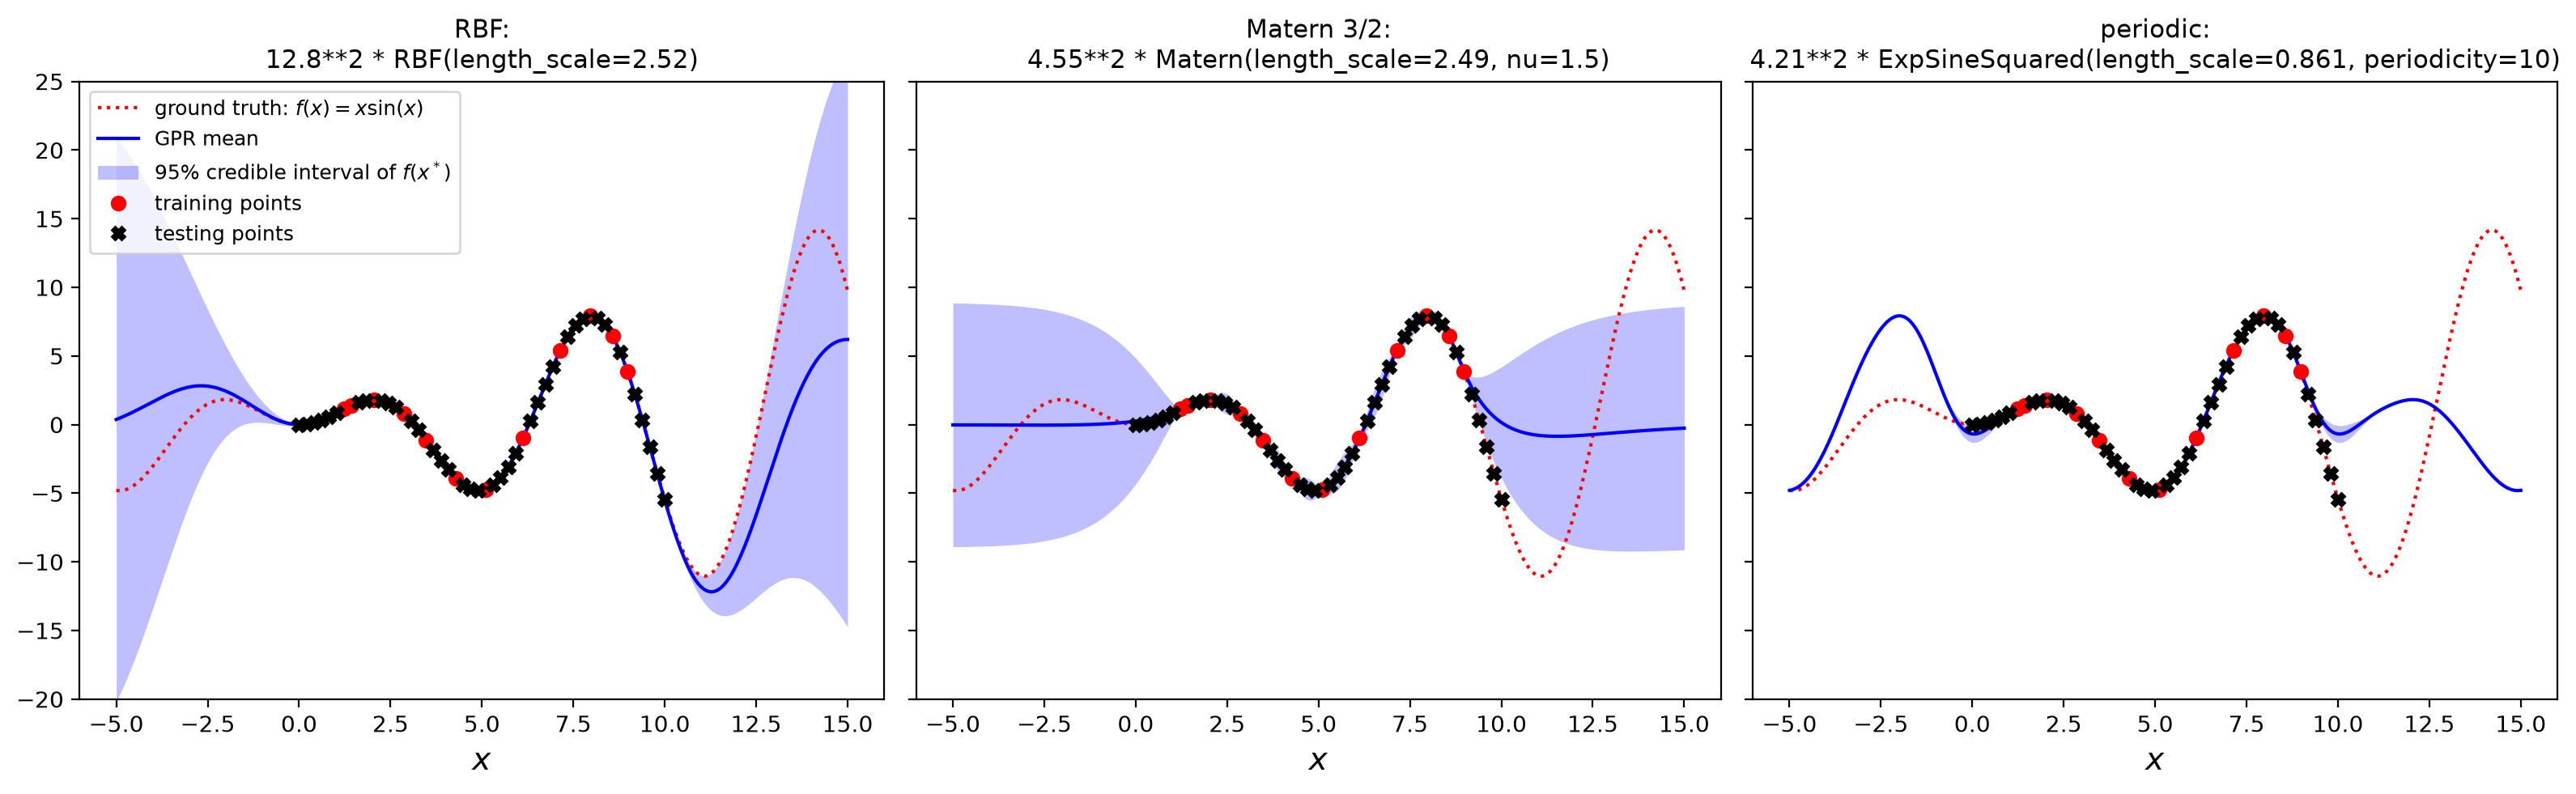

In [14]:
fig2

### Reading the kernels

* On the 38 testing points, between the training points, the **RBF** kernel is almost perfect, the **Matérn 3/2** a bit
  worse (it believes in rougher functions than $x\sin(x)$), and the **periodic** kernel good but not perfect: it believes
  that $f$ repeats, and it **extrapolates that belief** (look outside $[0, 10]$).
* The polynomial of degree 4 is far worse than any Gaussian process here.
* All of them extrapolate poorly: the GP returns to its prior mean, zero; the polynomial diverges. The kernel is a
  belief about $f$, and **choosing it is choosing a model** (Lecture 17).

### Gaussian Process regression for <font color='red'>noisy datasets</font>

Let's recreate the noisy dataset of Lecture 11, $f(x) = x\sin(x)$ plus noise whose standard deviation changes from point to point (heteroscedastic, as in Lecture 13).

First, assume that we **know** the noise variance $\sigma_i^2$ at every training point. Then it enters the PPD through the diagonal matrix $\boldsymbol{\Lambda} = \text{diag}(\sigma_1^2, \ldots, \sigma_N^2)$ (as in Lecture 13): in scikit-learn, $\alpha$ is then a **vector**, $\alpha_i = \sigma_i^2$.

* Knowing the noise at each training point is not common in practice. However, if you can do multiple measurements at each data point $x_i$ to determine the standard deviation of $y_i$ at that data point, then you can estimate the noise and include it in the "alpha" parameter of scikit-learn.

#### Notes: the PPD with a noise at each point

We concluded that the PPD for a Gaussian process with **heteroscedastic noise** is:

$${\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid \mu^* +
{\mathbf{k}^*}^T (\mathbf{K}+\boldsymbol{\Lambda})^{-1}(\mathbf{y}-\boldsymbol{\mu}) \,,\, {\sigma^*}^2 + k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T (\mathbf{K}+\boldsymbol{\Lambda})^{-1} \mathbf{k}^*\right)
$$

where usually the mean function ($\mu^*\equiv\mu(\mathbf{x}^*)$, and $\boldsymbol{\mu}$ at the training points) and $\sigma^* \equiv \sigma(\mathbf{x}^*)$ are **assumed to be zero**, and where the aleatoric uncertainty at training points (noise matrix $\boldsymbol{\Lambda}$) is often considered a diagonal matrix where each entry is the noise level at data point $\mathbf{x}_i$ (sometimes noise can be measured at every training point $\mathbf{x}_i$, but usually this information is not known):

$\Lambda_{ij} = \sigma_i^2\delta_{ij}$

where $\sigma_i \equiv \sigma(\mathbf{x}_i)$ is the noise assumed (or measured) at each training point $\mathbf{x}_i$, and $\delta_{ij}$ is the Kronecker delta (Identity matrix).

* In scikit-learn $\boldsymbol{\alpha}$ can also be a **vector**, i.e. $\alpha_i = \sigma_i^2$. This is one way of modeling heteroscedasticity (if you know the variance for your aleatoric uncertainty at each training point)

In [15]:
# Now let's also create the noisy dataset:
rng = np.random.default_rng(seed)
noise_std = 0.2 + 1.0 * rng.random(y_data.shape) # a random standard deviation in [0.2, 1.2) at each point
noise_samples = rng.normal(0, noise_std) # one draw from each of these Gaussians
y_noisy_data = y_data + noise_samples # Perturb every y_data point with Gaussian noise

# Pair up points with their associated noise level (because of train_test_split):
Y_noisy_data = np.column_stack((y_noisy_data,noise_std)) # note that we use "noise_std" (not "noise_samples")

# Split into training points and the rest for testing (according to testset_ratio):
X_train, X_test, Y_noisy_train, Y_noisy_test = train_test_split(X_data,
                                    Y_noisy_data, test_size=testset_ratio,
                                    random_state=seed) # "noisy_train" is a great name for a variable, hein?
# NOTE: since we are using the same seed and we do train_test_split on the same X_data and since y_noisy_data
#       is just y_data + noise, we are splitting the dataset exactly in the same way! This is nice because we
#       want to keep the comparison as fair as possible.

# Finally, for plotting purposes, let's convert the 2D arrays into 1D arrays (vectors):
x_train = X_train.ravel()
x_test = X_test.ravel()
y_noisy_train = Y_noisy_train[:,0]
noise_std_train = Y_noisy_train[:,1]
y_noisy_test = Y_noisy_test[:,0]
noise_std_test = Y_noisy_test[:,1]

print("Note that X_train and X_test are the same data that we used for the noiseless case.")
print("Also note that noise in training data is coming from a Gaussian with standard deviation:\n", noise_std_train)

Note that X_train and X_test are the same data that we used for the noiseless case.
Also note that noise in training data is coming from a Gaussian with standard deviation:
 [0.76624992 0.74662322 0.33188029 0.3251522  1.15471089 0.67044115
 0.95175405 0.42502173 0.90661897 1.04705601 0.50533566 0.84613564]


#### Notes

Now let's train a GP but considering that we know the heteroscedastic noise at every training data point

* Knowing the noise at each training point is not common in practice. However, if you can do multiple measurements at each data point $x_i$ to determine the standard deviation of $y_i$ at that data point, then you can estimate the noise and include it in the "alpha" parameter of scikit-learn.

fraction of the noisy testing points inside the band: 0.68 (band as plotted), 0.87 (band + known noise)


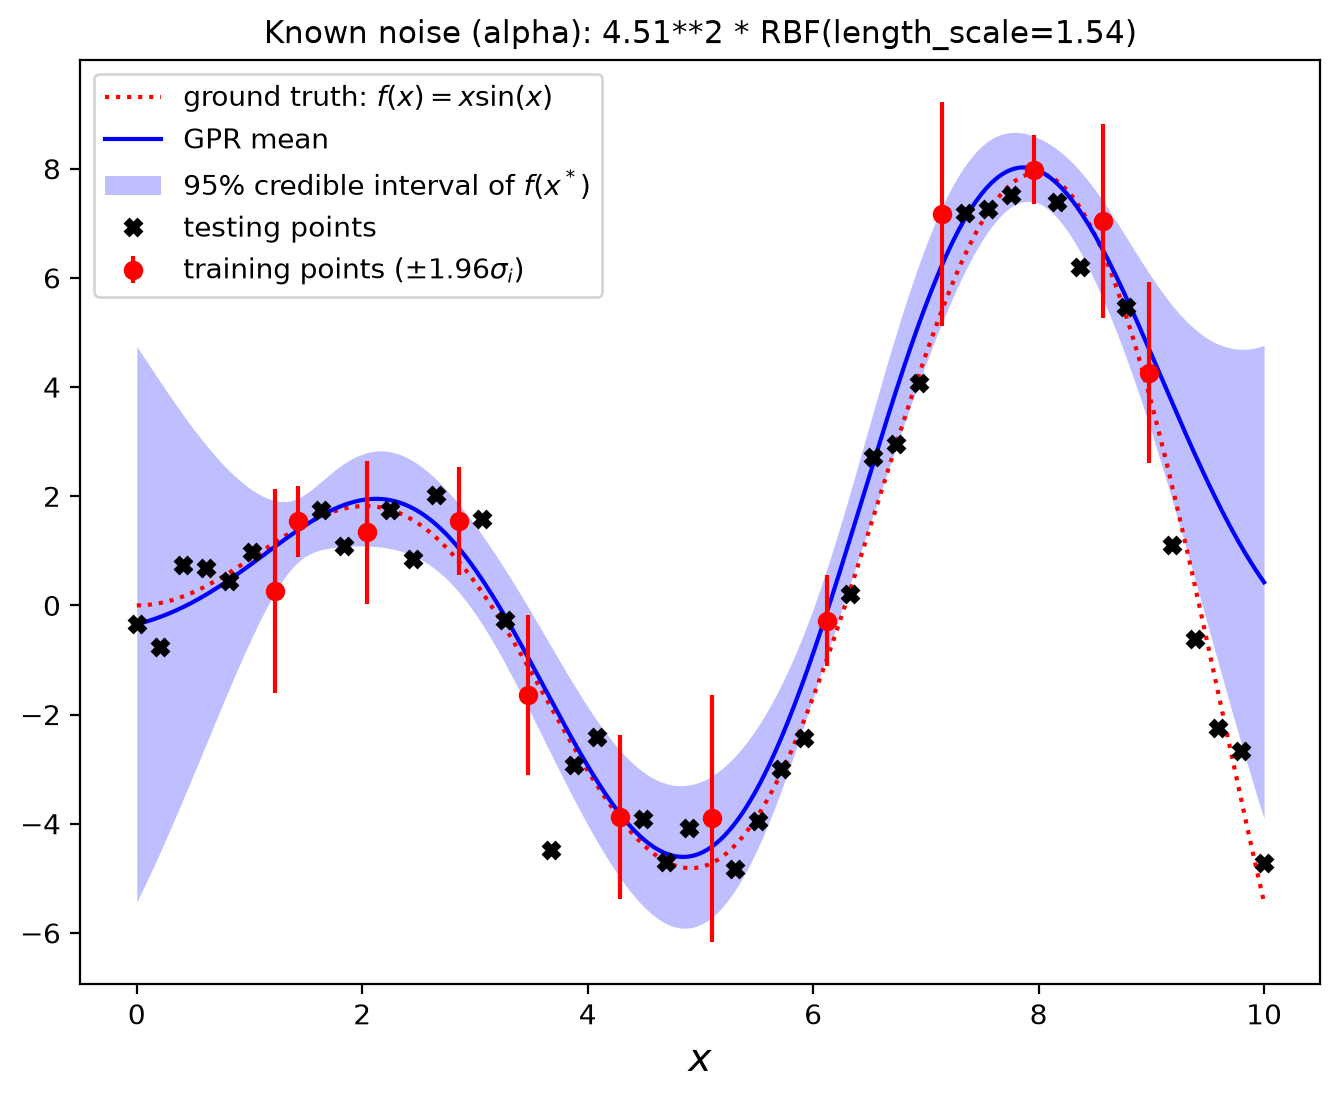

In [16]:
# The (known) noise variance at each training point goes in alpha
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2))
gp_model = GaussianProcessRegressor(kernel=kernel, alpha=noise_std_train**2, n_restarts_optimizer=5, random_state=0)
gp_model.fit(X_train, y_noisy_train)
mean, std = gp_model.predict(x_plot.reshape(-1, 1), return_std=True)
m, s = gp_model.predict(X_test, return_std=True)

fig3, ax3 = plt.subplots(figsize=(8, 6))
plot_gp(ax3, x_plot, mean, std, "Known noise (alpha): " + str(gp_model.kernel_), x_train, y_noisy_train, x_test,
        y_noisy_test, errorbars=noise_std_train)
ax3.legend(loc="upper left", fontsize=10); plt.close(fig3)
print("fraction of the noisy testing points inside the band: %.2f (band as plotted), %.2f (band + known noise)"
      % (np.mean(np.abs(y_noisy_test - m) <= 1.96 * s), np.mean(np.abs(y_noisy_test - m) <= 1.96 * np.sqrt(s**2 + noise_std_test**2))))
fig3

#### Note: the blue band and the error bars show different things

* The error bars on the points are the **95% interval of the (known) noise** at each point: $\pm 1.96\,\sigma_i$. Nothing is inferred there.
* The blue band is a **credible interval for $f(x^*)$**: the noise was given through `alpha`, so scikit-learn does not include it in the predicted std (see the note after the PPD at the beginning of this lecture).

Consequence: a "95%" band that excludes the noise is **not** expected to contain 95% of the noisy test points. Check it yourself:

```python
np.mean(np.abs(y_noisy_test - y_noisy_pred) <= 1.96*sigma_noisy)                              # band as plotted
np.mean(np.abs(y_noisy_test - y_noisy_pred) <= 1.96*np.sqrt(sigma_noisy**2 + noise_std_test**2)) # band + known noise
```

The second line is the **posterior predictive interval for $y^*$**, which is what you need if you want to predict a new *measurement*.

**But note that the second line is only possible here because the data are synthetic**: we *know* the noise at the test points, `noise_std_test`, just like we know the ground truth. In a real problem the noise at a new point $x^*$ is unknown, and to predict it you need a **model for the standard deviation as a function of the input**, $\sigma(x)$:

* interpolate the measured noise values $\sigma_i$ with a second model (e.g. a second GP on $\log \sigma_i$), which needs repeated measurements to estimate each $\sigma_i$ and ignores the uncertainty of $\sigma(x)$ itself; or
* learn both functions jointly, $p(y|x,\mathbf{z}) = \mathcal{N}\left(y\,|\,f(x),\, \sigma(x)^2\right)$, e.g. a heteroscedastic GP, or a neural network with two outputs $\mu(x)$ and $\sigma(x)$ trained on the Gaussian negative log likelihood (harder to train than it looks); or
* use a single constant noise level for all points (homoscedastic), which is what the White kernel below does.

### When the noise is **not** known: learn it with a White kernel

Add a **White kernel** to the kernel: its single hyperparameter is the noise variance, learned with the others (and then $\alpha \approx 0$):

$$
k(x_i,x_j) = {\color{red}s_1}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)} + {\color{red}s_2}^2\delta_{ij},
\qquad
{\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid {\mathbf{k}^*}^T \mathbf{K}^{-1}\mathbf{y} \,,\, k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T \mathbf{K}^{-1} \mathbf{k}^*\right)
$$

* The White kernel has a **single** noise level $s_2^2$ shared by all points: the model is **homoscedastic** (the one-$\sigma$ model of Lecture 13), even when the data, as here, are heteroscedastic. It can only learn an *average* noise level.
* Be careful: the optimization with a White kernel can be difficult with few training data, or with unreasonable bounds for its hyperparameter.

#### Notes: the White kernel in detail

In this case, however, you should not use the $\alpha$ parameter (assume it zero or close to zero).

The PPD for the Gaussian process where you want to **find the noise in your training points by setting it as a hyperparameter** instead of imposing the noise is then:

$${\color{orange}{p(y^*|\mathbf{x}^*, \mathcal{D})}} = \mathcal{N}\left( y^* \mid
{\mathbf{k}^*}^T \mathbf{K}^{-1}\mathbf{y} \,,\, k(\mathbf{x}^*, \mathbf{x}^*) - {\mathbf{k}^*}^T \mathbf{K}^{-1} \mathbf{k}^*\right)
$$

where you add a White kernel to the kernel function, for example use this kernel:

$$
k(x_i,x_j) = {\color{red}s_1}^2\exp{\left(-\frac{||x_i-x_j||^2}{2{\color{red}l}^2}\right)} + {\color{red}s_2}^2\delta_{ij}
$$

* **Note**: the White kernel has a *single* noise level $s_2^2$ shared by all points, so this model is **homoscedastic**, even when the data (as here) are heteroscedastic. It can only learn an *average* noise level.

* However, be careful! The hyperparameter optimization when you include the White kernel can be difficult if there is not enough training data and if you use unreasonable bounds for the hyperparameter of the white kernel... You can play with the cell below and understand what I mean...

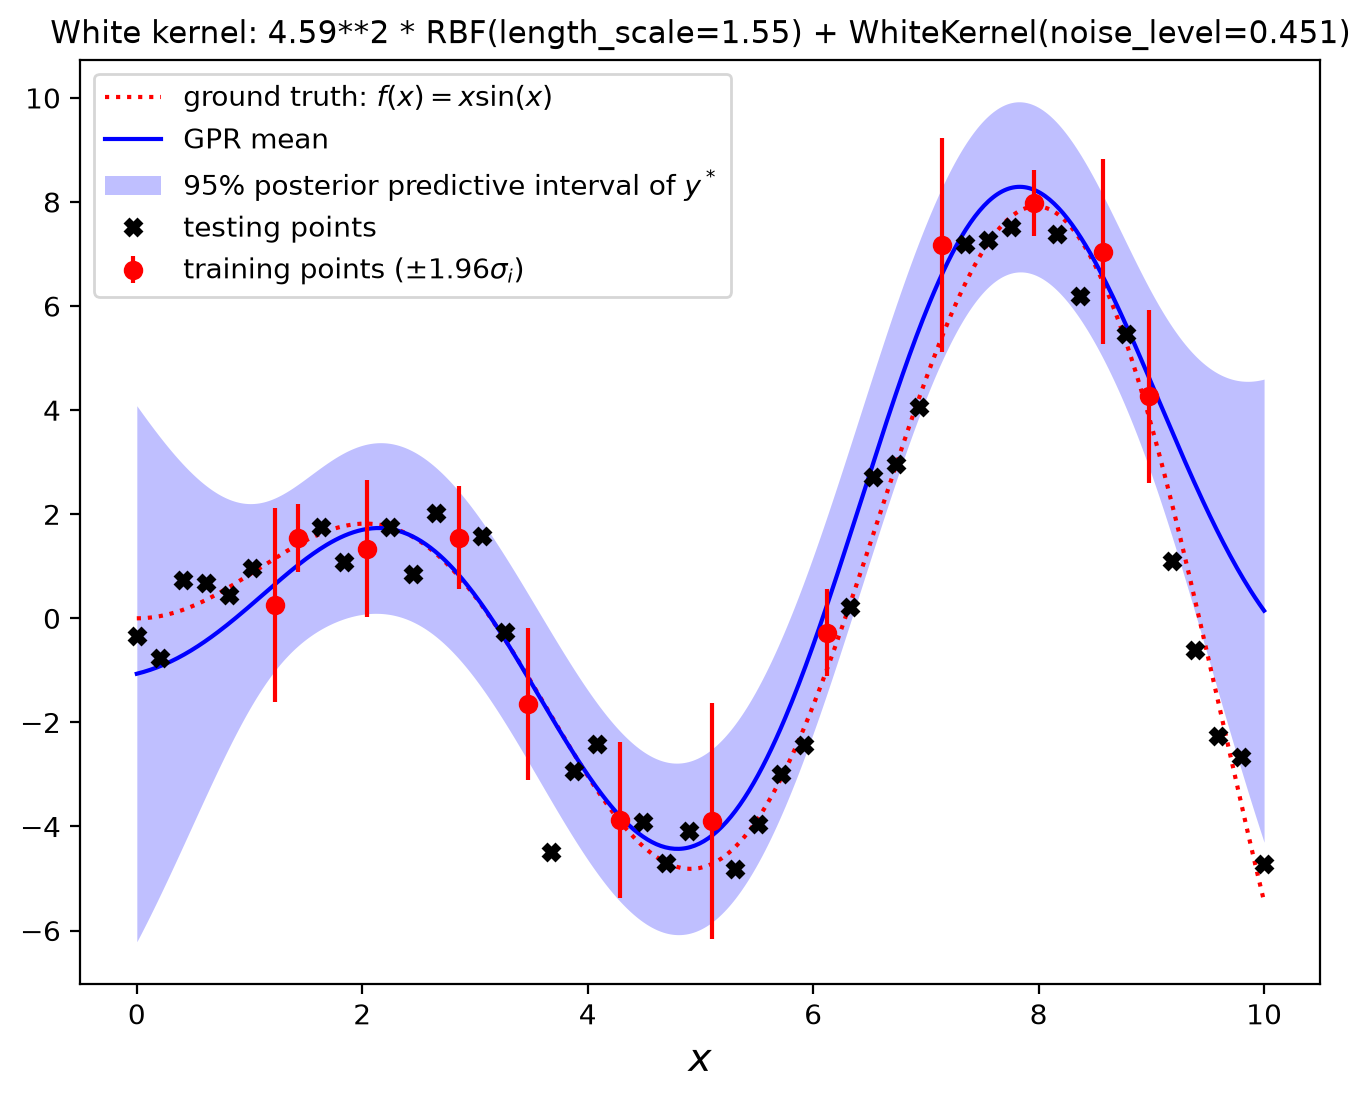

In [17]:
# The noise is NOT given: a White kernel learns it, so alpha is (almost) zero
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e2)) + WhiteKernel(1e-2, (1e-10, 1e1))
gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, n_restarts_optimizer=5, random_state=0)
gp_model.fit(X_train, y_noisy_train)
mean, std = gp_model.predict(x_plot.reshape(-1, 1), return_std=True)

fig4, ax4 = plt.subplots(figsize=(8, 6))
plot_gp(ax4, x_plot, mean, std, "White kernel: " + str(gp_model.kernel_), x_train, y_noisy_train, x_test, y_noisy_test,
        band="95% posterior predictive interval of $y^*$", errorbars=noise_std_train)
ax4.legend(loc="upper left", fontsize=10); plt.close(fig4)
fig4

#### Note: this blue band is a different interval from the previous one

With a `WhiteKernel`, the noise is part of the kernel, so the std returned by scikit-learn **includes** it: this band is a **posterior predictive interval for $y^*$**, i.e. it is meant to contain new noisy measurements. The band of the previous figure (noise through `alpha`) was a credible interval for $f(x^*)$ instead.

But this one relies on the noise that the model *learned*, and the White kernel learns a **single** noise level for heteroscedastic data. Compare the learned noise std, $\sqrt{s_2^2}$ (in the title of the figure), with the actual noise of the data, `noise_std_train`. With few training points it is typically too small, so the band still misses more than 5% of the noisy test points. Run the coverage check of the previous note with this model to see it, then repeat with `testset_ratio = 0.5` as suggested below.

### Reading the noise through Lecture 13

* **Known noise** ($\alpha_i = \sigma_i^2$): the aleatoric uncertainty is given, and the GP only learns the mean and the epistemic uncertainty.
* **White kernel**: one learned noise level, like the homoscedastic model of Lecture 13: right on average, wrong locally.
* **Learned heteroscedastic noise**: the staggered scheme of Lecture 13 works with a GP as the model of the mean (noise step, then a GP with $\alpha_i = \hat\sigma^2(x_i)$): you will try it in Homework 6.

#### Notes: how well does the White kernel learn the noise? (also in Homework 6)

With 12 training points, the answer depends a lot on the particular noise we drew. So let's repeat the experiment: 10
different draws of the noise, and 12, 25 or 37 training points (the same split as before, with `testset_ratio` 0.75,
0.5 and 0.25). Each time we compare the noise standard deviation learned by the White kernel with the root mean square
of the true noise at the training points.

In [18]:
rows = []
for draw in range(10):
    rng_d = np.random.default_rng(draw)
    sd_d = 0.2 + 1.0 * rng_d.random(50)
    y_d = y_data + rng_d.normal(0, sd_d)
    for ratio in (0.75, 0.5, 0.25):
        Xtr_d, _, Ytr_d, _ = train_test_split(X_data, np.column_stack((y_d, sd_d)), test_size=ratio, random_state=seed)
        gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, n_restarts_optimizer=5, random_state=0)
        gp_model.fit(Xtr_d, Ytr_d[:, 0])                  # the same kernel (RBF + White) as above
        learned = np.sqrt(gp_model.kernel_.k2.noise_level) # the fitted noise variance, as a standard deviation
        rows.append(dict(draw=draw, N=len(Xtr_d), learned=learned, true_rms=np.sqrt(np.mean(Ytr_d[:, 1]**2))))
tab = pd.DataFrame(rows)
tab["ratio"] = tab.learned / tab.true_rms
print(tab.pivot(index="draw", columns="N", values="ratio").round(2).to_string())
print("\nlearned / true noise, over the 10 draws:\n", tab.groupby("N").ratio.describe()[["mean", "min", "max"]].round(2).to_string())

N       12    25    37
draw                  
0     0.60  0.71  0.91
1     0.76  2.04  0.65
2     1.27  1.15  1.12
3     0.29  0.85  1.09
4     0.23  0.62  0.95
5     0.90  0.85  0.89
6     0.17  0.77  1.00
7     0.81  0.78  0.70
8     1.21  1.31  1.16
9     0.84  0.94  0.87

learned / true noise, over the 10 draws:
     mean   min   max
N                   
12  0.71  0.17  1.27
25  1.00  0.62  2.04
37  0.94  0.65  1.16


* With 12 points, the learned noise ranges from about **0.2 to 1.3 times** the true one, depending on the draw: one
  experiment tells you little.
* With 37 points, it stays within about **0.65 to 1.15 times** the true one.
* Learning the noise needs data: the White kernel is one more hyperparameter to estimate, and with few points the
  optimizer can explain the noise as signal (a short length scale) or the signal as noise.

**Note:** choosing between kernels (and their hyperparameter bounds) is itself a model-selection problem. You can do it
with $k$-fold cross-validation on the training set (Lecture 11) and grid search (the notes of Lecture 12), or with the
marginal likelihood (Lecture 17).

## Field guide: what this lecture adds

### Key concepts

**Models**
- **A prior on the weights is a prior on functions, and the kernel is its covariance**: with random weights, $f(\mathbf{x}) = \boldsymbol{\phi}(\mathbf{x})^T\mathbf{w}$ is a random function, and its values at any set of inputs are jointly Gaussian with covariance $k(\mathbf{x}, \mathbf{x}') = \boldsymbol{\phi}(\mathbf{x})^T\overset{\scriptscriptstyle <}{\boldsymbol{\Sigma}}_w\boldsymbol{\phi}(\mathbf{x}')$ (the same prior seen from the weights or from the functions). A kernel gives this covariance directly, gathering the basis functions and the prior on their weights into one object, possibly with infinitely many basis functions; with a zero mean it fully specifies the prior (a Gaussian process). Its hyperparameters are fixed numbers that set the prior variances of the weights: $s$ the amplitude of the functions, $l$ the length scale over which they change.
- **Not every function is a kernel**: a kernel must be positive semi-definite (Mercer's theorem). Sums and products of valid kernels are valid kernels: a sum gives the properties of either kernel, a product of both.

The whole [field guide](https://github.com/bessagroup/3dasm_course/blob/main/FIELD_GUIDE.md) collects the key concepts and good practices of every lecture.

### See you next class

Next lecture: Gaussian processes with more than one input, why we scale the data, and what Gaussian processes cost.

You will explore these and other things in Homework 6. Have fun!